<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/GW190814_Posterior_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GW190814_cosmo.h5 already exists; skipping download.
File size: 159.6 MB
Header bytes: b'\x89HDF\r\n\x1a\n'
Top-level keys: ['C01:IMRPhenomXPHM', 'C01:Mixed', 'history', 'version']
Using object: /C01:Mixed/posterior_samples
Object type: <class 'h5py._hl.dataset.Dataset'>

Loaded columns:
['temperature', 'mass_ratio', 'peak_luminosity', 'V1_time', 'cos_iota', 'final_mass_source', 'L1_spcal_phase_3', 'V1_spcal_phase_4', 'spin_2z', 'V1_spcal_amp_0', 'total_mass', 'H1_spcal_phase_4', 'spin_1z', 'log_likelihood', 'loglH1', 'chain_delta_log_evidence', 'psi_J', 'radiated_energy', 'H1_spcal_amp_7', 'L1_spcal_amp_9', 'L1_time', 'redshift', 'H1_time', 'chain_log_bayes_factor', 'mass_2_source', 'H1_spcal_phase_0', 'V1_spcal_amp_7', 'L1_spcal_amp_4', 'cos_theta_jn', 'V1_matched_filter_snr', 'inverted_mass_ratio', 'total_mass_source', 'H1_spcal_phase_3', 'psi', 'L1_spcal_amp_3', 'symmetric_mass_ratio', 'H1_spcal_amp_3', 'H1_spcal_phase_1', 'L1_spcal_amp_8', 'L1_spcal_phase_2', 'L1_matched_filter_sn

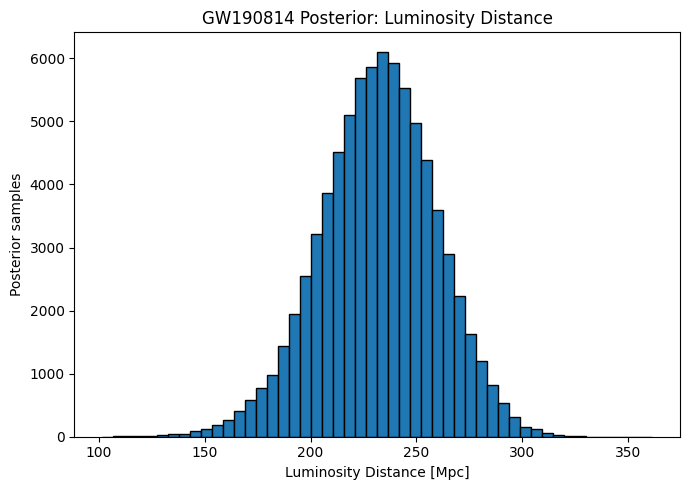

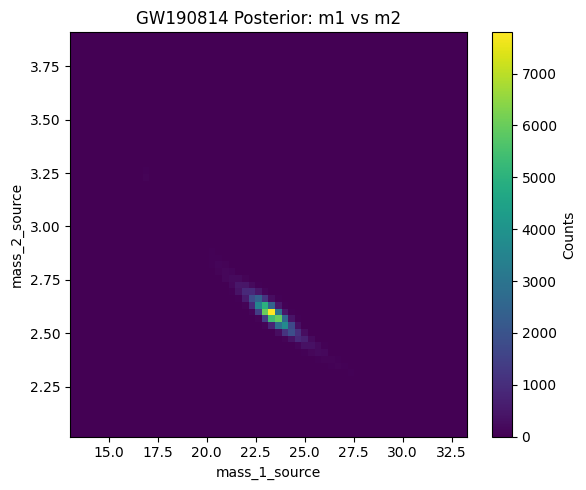

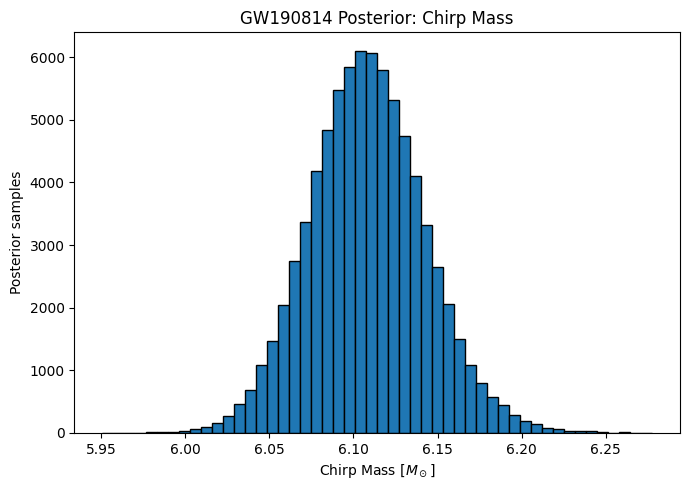

In [4]:
import os
import requests
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False


# ============================================================
# CONFIG
# ============================================================
URL = "https://zenodo.org/records/6513631/files/IGWN-GWTC2p1-v2-GW190814_211039_PEDataRelease_mixed_cosmo.h5?download=1"
POSTERIOR_FILE = "GW190814_cosmo.h5"


# ============================================================
# DOWNLOAD
# ============================================================
def download_file(url, output_path, chunk_size=1024 * 1024):
    print(f"Downloading to {output_path} ...")
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        downloaded = 0

        with open(output_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    if total > 0:
                        pct = 100 * downloaded / total
                        print(f"\r{downloaded/1024**2:7.1f} MB / {total/1024**2:7.1f} MB ({pct:5.1f}%)", end="")
    print("\nDownload complete.")


if not os.path.exists(POSTERIOR_FILE):
    download_file(URL, POSTERIOR_FILE)
else:
    print(f"{POSTERIOR_FILE} already exists; skipping download.")


# ============================================================
# SANITY CHECK
# ============================================================
size_mb = os.path.getsize(POSTERIOR_FILE) / (1024**2)
print(f"File size: {size_mb:.1f} MB")

with open(POSTERIOR_FILE, "rb") as f:
    header = f.read(8)

print("Header bytes:", header)
if header != b"\x89HDF\r\n\x1a\n":
    raise ValueError("Downloaded file is not a valid HDF5 file.")


# ============================================================
# HELPERS
# ============================================================
def find_posterior_object(h5obj):
    """
    Locate the posterior samples object in common GW posterior layouts.
    Returns either an h5py Group or Dataset.
    """
    candidate_paths = [
        "posterior_samples",
        "samples",
        "C01:Mixed/posterior_samples",
        "C01:Mixed",
        "PublicationSamples/posterior_samples",
        "PublicationSamples",
    ]

    for path in candidate_paths:
        if path in h5obj:
            return h5obj[path]

    found = []

    def visitor(name, obj):
        if name.endswith("posterior_samples"):
            found.append(name)

    h5obj.visititems(visitor)

    if found:
        print("Found posterior object:", found[0])
        return h5obj[found[0]]

    raise ValueError("Could not find posterior samples in this HDF5 file.")


def object_to_dataframe(obj):
    """
    Convert either:
      - an HDF5 Group of 1D datasets
      - or a structured HDF5 Dataset
    into a pandas DataFrame.
    """
    # Case 1: structured dataset
    if isinstance(obj, h5py.Dataset):
        arr = obj[()]
        if arr.dtype.names is None:
            raise ValueError("Dataset found, but it is not a structured array with named fields.")
        return pd.DataFrame({name: arr[name] for name in arr.dtype.names})

    # Case 2: group of datasets
    elif isinstance(obj, h5py.Group):
        data = {}
        lengths = []

        for key in obj.keys():
            item = obj[key]
            if isinstance(item, h5py.Dataset):
                arr = item[()]
                if np.ndim(arr) == 1:
                    data[key] = arr
                    lengths.append(len(arr))

        if not data:
            raise ValueError("No suitable 1D datasets found in posterior group.")

        from collections import Counter
        target_len = Counter(lengths).most_common(1)[0][0]
        data = {k: v for k, v in data.items() if len(v) == target_len}

        return pd.DataFrame(data)

    else:
        raise TypeError(f"Unsupported HDF5 object type: {type(obj)}")


def load_posterior_dataframe(filename):
    with h5py.File(filename, "r") as f:
        print("Top-level keys:", list(f.keys()))
        obj = find_posterior_object(f)
        print("Using object:", obj.name)
        print("Object type:", type(obj))
        df = object_to_dataframe(obj)
    return df


def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns were found: {candidates}")


# ============================================================
# LOAD POSTERIORS
# ============================================================
df = load_posterior_dataframe(POSTERIOR_FILE)

print("\nLoaded columns:")
print(df.columns.tolist())
print(f"\nLoaded {len(df)} posterior samples")


# ============================================================
# IDENTIFY PARAMETERS
# ============================================================
dL_col = first_existing_column(df, ["luminosity_distance", "distance", "dL"])
m1_col = first_existing_column(df, ["mass_1_source", "mass_1", "m1_source", "m1"])
m2_col = first_existing_column(df, ["mass_2_source", "mass_2", "m2_source", "m2"])

chirp_col = None
for c in ["chirp_mass_source", "chirp_mass", "chirp_mass_source_non_evolved", "mc_source", "mc"]:
    if c in df.columns:
        chirp_col = c
        break

if chirp_col is None:
    df["chirp_mass_computed"] = (
        (df[m1_col] * df[m2_col]) ** (3/5)
        / (df[m1_col] + df[m2_col]) ** (1/5)
    )
    chirp_col = "chirp_mass_computed"

print("\nUsing columns:")
print(" distance  =", dL_col)
print(" mass 1    =", m1_col)
print(" mass 2    =", m2_col)
print(" chirp mass=", chirp_col)


# ============================================================
# 1) HISTOGRAM OF LUMINOSITY DISTANCE
# ============================================================
plt.figure(figsize=(7, 5))
plt.hist(df[dL_col].dropna(), bins=50, edgecolor="black")
plt.xlabel("Luminosity Distance [Mpc]")
plt.ylabel("Posterior samples")
plt.title("GW190814 Posterior: Luminosity Distance")
plt.tight_layout()
plt.show()


# ============================================================
# 2) M1 VS M2 CORNER-STYLE PLOT
# ============================================================
samples_m1m2 = df[[m1_col, m2_col]].dropna().values

if HAS_CORNER:
    fig = corner.corner(
        samples_m1m2,
        labels=[m1_col, m2_col],
        show_titles=True,
        title_fmt=".2f",
        bins=40,
        smooth=1.0
    )
    fig.suptitle("GW190814 Posterior: m1 vs m2", y=1.02)
    plt.show()
else:
    plt.figure(figsize=(6, 5))
    plt.hist2d(df[m1_col], df[m2_col], bins=60)
    plt.xlabel(m1_col)
    plt.ylabel(m2_col)
    plt.title("GW190814 Posterior: m1 vs m2")
    plt.colorbar(label="Counts")
    plt.tight_layout()
    plt.show()


# ============================================================
# 3) HISTOGRAM OF CHIRP MASS
# ============================================================
plt.figure(figsize=(7, 5))
plt.hist(df[chirp_col].dropna(), bins=50, edgecolor="black")
plt.xlabel("Chirp Mass [$M_\\odot$]")
plt.ylabel("Posterior samples")
plt.title("GW190814 Posterior: Chirp Mass")
plt.tight_layout()
plt.show()

In [8]:
!pip install corner

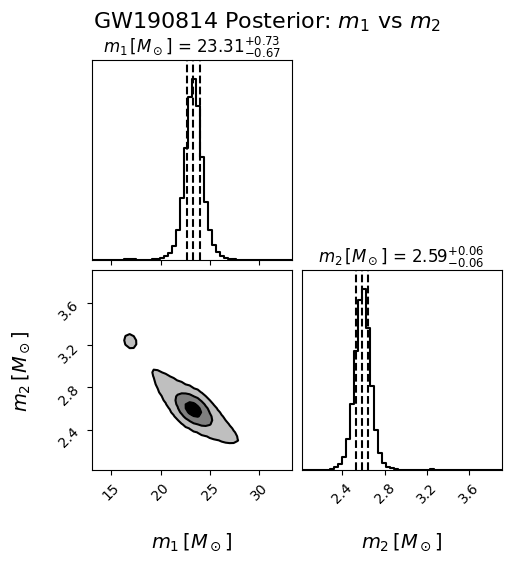

In [9]:
import corner
import matplotlib.pyplot as plt

samples_m1m2 = df[[m1_col, m2_col]].dropna().values

fig = corner.corner(
    samples_m1m2,
    labels=[r"$m_1\,[M_\odot]$", r"$m_2\,[M_\odot]$"],
    bins=50,
    smooth=1.2,
    smooth1d=1.2,
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.393, 0.865, 0.989),   # ~1σ, 2σ, 3σ for 2D contours
    plot_density=True,
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=5,
    label_kwargs={"fontsize": 14},
    title_kwargs={"fontsize": 12},
)

fig.suptitle("GW190814 Posterior: $m_1$ vs $m_2$", y=1.02, fontsize=16)
plt.show()

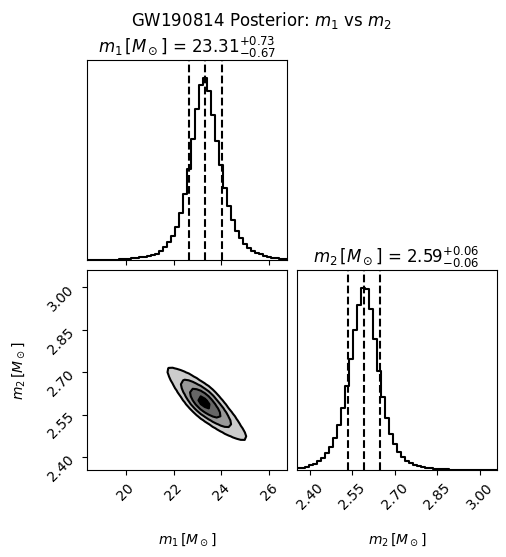

In [10]:
m1 = df[m1_col].dropna()
m2 = df[m2_col].dropna()

m1_lo, m1_hi = np.percentile(m1, [0.5, 99.5])
m2_lo, m2_hi = np.percentile(m2, [0.5, 99.5])

samples_m1m2 = df[[m1_col, m2_col]].dropna().values

fig = corner.corner(
    samples_m1m2,
    labels=[r"$m_1\,[M_\odot]$", r"$m_2\,[M_\odot]$"],
    range=[(m1_lo, m1_hi), (m2_lo, m2_hi)],
    bins=50,
    smooth=1.0,
    smooth1d=1.0,
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    plot_datapoints=False,
    fill_contours=True,
    plot_density=True,
    max_n_ticks=5,
)

fig.suptitle("GW190814 Posterior: $m_1$ vs $m_2$", y=1.02)
plt.show()

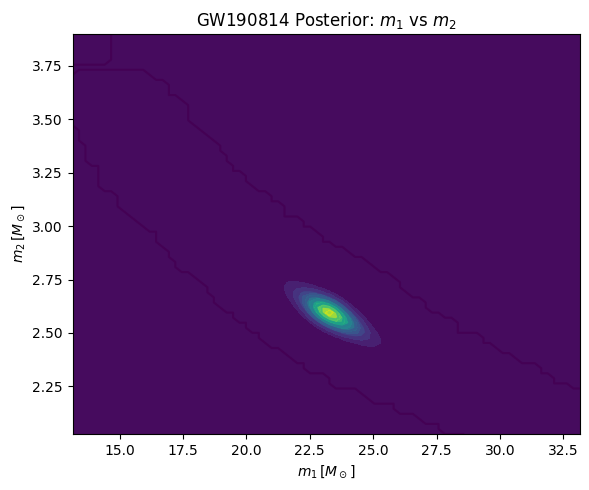

In [7]:
from scipy.ndimage import gaussian_filter

m1 = df[m1_col].dropna().values
m2 = df[m2_col].dropna().values

H, xedges, yedges = np.histogram2d(m1, m2, bins=80)
H = gaussian_filter(H, sigma=1.2)

xcent = 0.5 * (xedges[:-1] + xedges[1:])
ycent = 0.5 * (yedges[:-1] + yedges[1:])

plt.figure(figsize=(6, 5))
plt.contourf(xcent, ycent, H.T, levels=20)
plt.contour(xcent, ycent, H.T, levels=6)
plt.xlabel(r"$m_1\,[M_\odot]$")
plt.ylabel(r"$m_2\,[M_\odot]$")
plt.title("GW190814 Posterior: $m_1$ vs $m_2$")
plt.tight_layout()
plt.show()

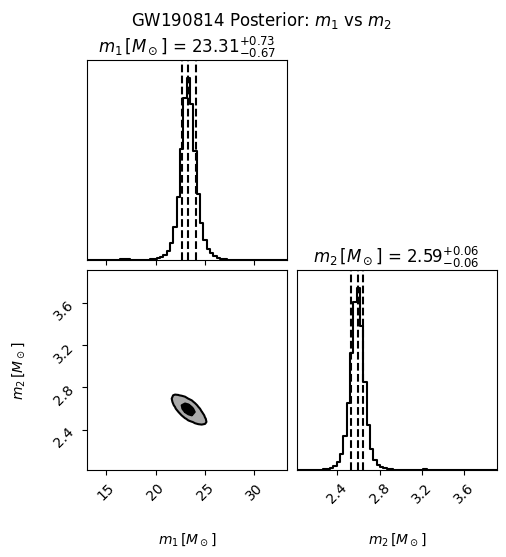

In [11]:
import corner
import matplotlib.pyplot as plt
import numpy as np

m1 = df[m1_col].dropna()
m2 = df[m2_col].dropna()

samples = np.vstack([m1, m2]).T

fig = corner.corner(
    samples,
    labels=[r"$m_1\,[M_\odot]$", r"$m_2\,[M_\odot]$"],
    bins=60,
    smooth=1.0,
    smooth1d=1.0,
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.393, 0.865),  # ~1σ and 2σ (cleaner than 3 levels)
    plot_datapoints=False,
    fill_contours=True,
    plot_density=True,
    max_n_ticks=5,
)

fig.suptitle("GW190814 Posterior: $m_1$ vs $m_2$", y=1.02)
plt.show()